Importing

In [78]:
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans

DATASET:

link: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python <br>

* This file contains the basic information (ID, age, gender, income, spending score) about the customers
* CustomerID: Unique ID assigned to the customer
* Gender: Gender of the customer
* Age: Age of the customer
* Annual Income (k$): Annual Income of the customer
* Spending Score (1-100): Score assigned by the mall based on customer behavior and spending nature

In [79]:
dataframe = pd.read_csv("/content/Mall_Customers.csv")
dataframe.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Altering dataset to our use

In [80]:
dataframe["Gender"] = (dataframe["Gender"] == "Male").astype(int)
dataframe = dataframe.drop("CustomerID", axis=1)
dataframe.rename(columns={"Annual Income (k$)": "AnnualIncome(k$)", "Spending Score (1-100)": "SpendingScore(1-100)"}, inplace=True)
dataframe.head()

,Gender,Age,AnnualIncome(k$),SpendingScore(1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


Basic EDA

In [90]:
print(f"{dataframe.isnull().sum()}") # No null values
dataframe.describe()

Gender                  0
Age                     0
AnnualIncome(k$)        0
SpendingScore(1-100)    0
prediction              0
dtype: int64


,Gender,Age,AnnualIncome(k$),SpendingScore(1-100),prediction
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,0.440000,38.850000,60.560000,50.200000,2.470000
std,0.497633,13.969007,26.264721,25.823522,1.452463
min,0.000000,18.000000,15.000000,1.000000,0.000000
25%,0.000000,28.750000,41.500000,34.750000,1.000000
50%,0.000000,36.000000,61.500000,50.000000,3.000000
75%,1.000000,49.000000,78.000000,73.000000,4.000000
max,1.000000,70.000000,137.000000,99.000000,4.000000


In [88]:
print(f"Number of records: {len(dataframe)}")
print(f"Number of male candidates: {len(dataframe[dataframe['Gender'] == 1])}")
print(f"Number of female candidates: {len(dataframe[dataframe['Gender'] == 0])}")
print(f"Number of candidates with income greator then average: {len(dataframe[dataframe['AnnualIncome(k$)'] > dataframe['AnnualIncome(k$)'].mean()])}")
print(f"Number of candidates with spending score greator then average: {len(dataframe[dataframe['SpendingScore(1-100)'] > dataframe['SpendingScore(1-100)'].mean()])}")

Number of records: 200
Number of male candidates: 88
Number of female candidates: 112
Number of candidates with income greator then average: 102
Number of candidates with spending score greator then average: 97


Age vs Annual Income

<Axes: xlabel='Age', ylabel='AnnualIncome(k$)'>

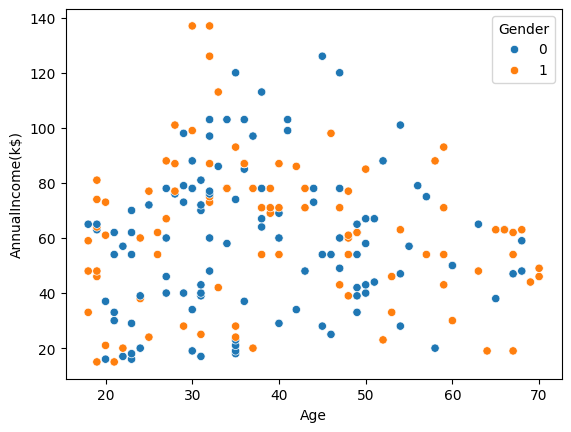

In [83]:
sns.scatterplot(data=dataframe, x="Age", y="AnnualIncome(k$)", hue="Gender")

Age vs SpendingScore (The more the age the less spendings)

<Axes: xlabel='Age', ylabel='SpendingScore(1-100)'>

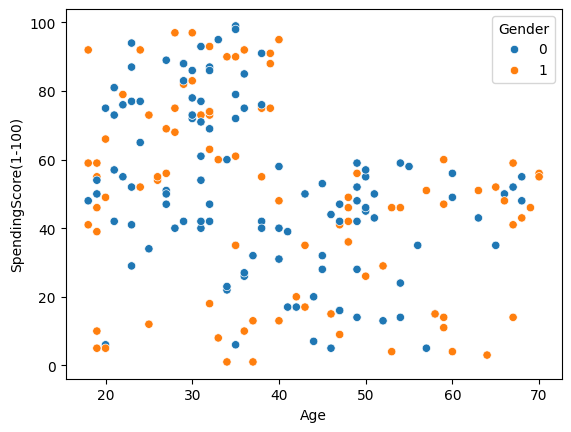

In [84]:
sns.scatterplot(data=dataframe, x="Age", y="SpendingScore(1-100)", hue="Gender")

Graph to will be grouped by KMean Clustering

<Axes: xlabel='AnnualIncome(k$)', ylabel='SpendingScore(1-100)'>

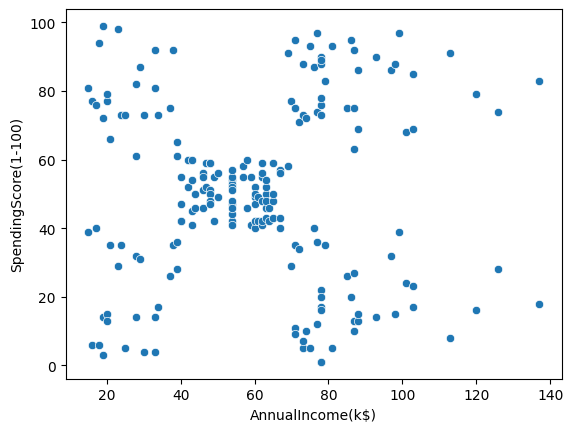

In [85]:
sns.scatterplot(data=dataframe, x="AnnualIncome(k$)", y="SpendingScore(1-100)")

Model: Kmean Clustering

In [86]:
prediction = KMeans(n_clusters=5).fit_predict(dataframe[["Gender", "Age", "AnnualIncome(k$)", "SpendingScore(1-100)"]])
dataframe["prediction"] = prediction
dataframe.head()

,Gender,Age,AnnualIncome(k$),SpendingScore(1-100),prediction
0,1,19,15,39,0
1,1,21,15,81,3
2,0,20,16,6,0
3,0,23,16,77,3
4,0,31,17,40,0


Prediction by K mean clustering

<Axes: xlabel='AnnualIncome(k$)', ylabel='SpendingScore(1-100)'>

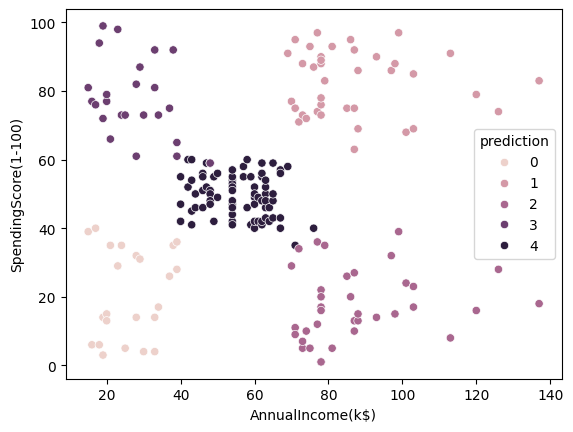

In [87]:
sns.scatterplot(data=dataframe, x="AnnualIncome(k$)", y="SpendingScore(1-100)", hue="prediction")